# Лабораторная работа №1: Обнаружение и распознавание объектов

Датасет: [YOLOv5 Game Dataset for Darknet](https://www.kaggle.com/datasets/maxkav/yolov5-game-dataset-for-darknet-framework)

Классы: coconut, dandelion-empty, dandelion-full, fluff, palm

Задача: обнаружение игровых объектов на скриншотах

## Структура ноутбука

1. Пункт 1: Выбор начальных условий (датасет + метрики)
2. Пункт 2: Создание бейзлайна — YOLOv11 (n/s/m) + RT-DETR
3. Пункт 3: Улучшение бейзлайна (гипотезы)
4. Пункт 4: Самостоятельная реализация детектора

## Метрики качества

- mAP@50 — средняя точность при IoU=0.5 (основная метрика для задач детекции)
- mAP@50-95 — усредненная mAP по IoU от 0.5 до 0.95 с шагом 0.05 (более строгая)
- Precision — точность (доля истинных срабатываний среди всех срабатываний)
- Recall — полнота (доля найденных объектов от всех реальных)

Обоснование: для задачи детекции объектов стандартом является mAP. Precision и Recall помогают понять баланс между ложными срабатываниями и пропусками.

## Установка зависимостей

In [1]:
!pip install -q ultralytics torch torchvision kagglehub opencv-python matplotlib seaborn pandas pyyaml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 26.2 MB/s eta 0:00:00


In [2]:
import os
import random
import shutil
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import torch

LAB_DIR = Path.cwd()
DATASET_DIR = LAB_DIR / "dataset"
RUNS_DIR = LAB_DIR / "runs"
RESULTS_DIR = LAB_DIR / "results"

for d in (DATASET_DIR, RUNS_DIR, RESULTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Устройство: {DEVICE}")
print(f"Рабочая директория: {LAB_DIR}")

Устройство: cuda
Рабочая директория: /content


# Пункт 1: Начальные условия

## a) Датасет

YOLOv5 Game Dataset for Darknet Framework — набор скриншотов из игры с размеченными игровыми объектами.

- Количество изображений: ~638
- Классы: 5 (coconut, dandelion-empty, dandelion-full, fluff, palm)

Обоснование выбора: реальная практическая задача — автоматический поиск интерактивных объектов на игровых сценах для игрового бота/автоматизации. Датасет небольшой, но разнообразный (3 локации), что делает задачу не тривиальной.

## b) Метрики

- mAP@50 — основная метрика (стандарт для детекции)
- mAP@50-95 — строгая оценка качества боксов
- Precision/Recall — для анализа баланса FP/FN

In [3]:
import kagglehub

DATASET_SLUG = "maxkav/yolov5-game-dataset-for-darknet-framework"
RAW_DIR = DATASET_DIR / "raw"

if not RAW_DIR.exists() or not any(RAW_DIR.iterdir()):
    print(f"Скачивание: {DATASET_SLUG}")
    cached_path = Path(kagglehub.dataset_download(DATASET_SLUG))
    print(f"Кеш: {cached_path}")

    RAW_DIR.mkdir(parents=True, exist_ok=True)
    for item in cached_path.iterdir():
        dest = RAW_DIR / item.name
        if dest.exists():
            continue
        if item.is_dir():
            shutil.copytree(item, dest)
        else:
            shutil.copy2(item, dest)

print(f"Содержимое {RAW_DIR}:")
for item in sorted(RAW_DIR.iterdir()):
    if item.is_dir():
        print(f"  {item.name}/ ({len(list(item.iterdir()))} файлов)")
    else:
        print(f"  {item.name}")

Скачивание: maxkav/yolov5-game-dataset-for-darknet-framework


100%|██████████| 309M/309M [00:02<00:00, 156MB/s]

Extracting files...


Кеш: /root/.cache/kagglehub/datasets/maxkav/yolov5-game-dataset-for-darknet-framework/versions/1
Содержимое /content/dataset/raw:
  classes.txt
  images/ (638 файлов)
  labels/ (638 файлов)
  notes.json


## Разбиение на train/val/test и создание dataset.yaml

In [4]:
CLASS_NAMES = ["coconut", "dandelion-empty", "dandelion-full", "fluff", "palm"]
IMAGE_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
SEED = 42
TRAIN_RATIO, VAL_RATIO = 0.7, 0.2

images_dir = RAW_DIR / "images"
labels_dir = RAW_DIR / "labels"

pairs = []
for img_path in sorted(images_dir.iterdir()):
    if img_path.suffix.lower() not in IMAGE_EXT:
        continue
    lbl_path = labels_dir / (img_path.stem + ".txt")
    if lbl_path.exists():
        pairs.append((img_path, lbl_path))

print(f"Найдено {len(pairs)} пар изображение-метка")

random.seed(SEED)
random.shuffle(pairs)
n = len(pairs)
train_end = int(n * TRAIN_RATIO)
val_end = train_end + int(n * VAL_RATIO)
splits = {
    "train": pairs[:train_end],
    "val": pairs[train_end:val_end],
    "test": pairs[val_end:],
}

for split_name, split_pairs in splits.items():
    img_out = DATASET_DIR / split_name / "images"
    lbl_out = DATASET_DIR / split_name / "labels"
    img_out.mkdir(parents=True, exist_ok=True)
    lbl_out.mkdir(parents=True, exist_ok=True)
    for img_src, lbl_src in split_pairs:
        if not (img_out / img_src.name).exists():
            shutil.copy2(img_src, img_out / img_src.name)
        if not (lbl_out / lbl_src.name).exists():
            shutil.copy2(lbl_src, lbl_out / lbl_src.name)
    print(f"  {split_name}: {len(split_pairs)} изображений")

config = {
    "path": str(DATASET_DIR.resolve()),
    "train": "train/images",
    "val": "val/images",
    "test": "test/images",
    "names": {i: n for i, n in enumerate(CLASS_NAMES)},
}
DATASET_YAML = DATASET_DIR / "dataset.yaml"
with open(DATASET_YAML, "w") as f:
    yaml.dump(config, f, allow_unicode=True)

print(f"\ndataset.yaml создан: {DATASET_YAML}")

Найдено 638 пар изображение-метка
  train: 446 изображений
  val: 127 изображений
  test: 65 изображений

dataset.yaml создан: /content/dataset/dataset.yaml


## Визуализация примеров из датасета

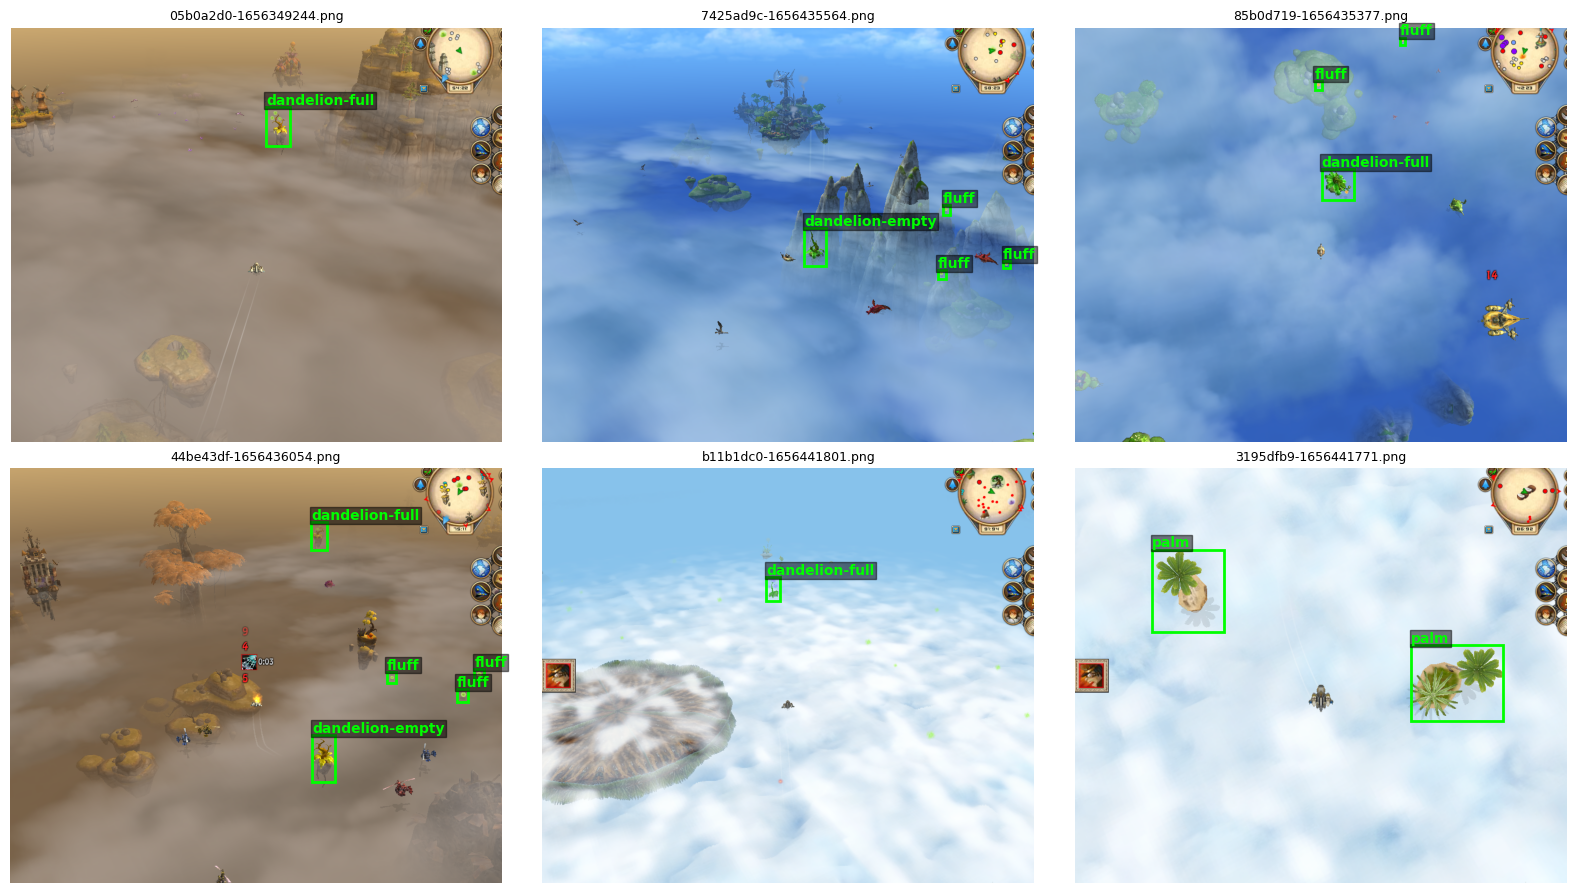

In [6]:
import cv2
import matplotlib.patches as patches

def draw_sample(img_path, lbl_path, ax):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    ax.imshow(img)

    if lbl_path.exists():
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    cls, xc, yc, bw, bh = parts[:5]
                    xc, yc, bw, bh = map(float, (xc, yc, bw, bh))
                    x1 = (xc - bw / 2) * w
                    y1 = (yc - bh / 2) * h
                    rect = patches.Rectangle(
                        (x1, y1), bw * w, bh * h,
                        linewidth=2, edgecolor="lime", facecolor="none"
                    )
                    ax.add_patch(rect)
                    ax.text(x1, y1 - 5, CLASS_NAMES[int(cls)],
                            color="lime", fontsize=10, fontweight="bold",
                            bbox=dict(facecolor="black", alpha=0.5, pad=1))
    ax.set_title(img_path.name, fontsize=9)
    ax.axis("off")

sample_pairs = random.Random(0).sample(splits["train"], 6)
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for (img_p, lbl_p), ax in zip(sample_pairs, axes.flat):
    draw_sample(img_p, lbl_p, ax)
plt.tight_layout()
plt.show()

# Пункт 2: Бейзлайн

Обучаем несколько моделей из ultralytics:

- **Сверточные**: YOLOv11n, YOLOv11s, YOLOv11m (разные размеры для сравнения)
- **Трансформерная**: RT-DETR-L (на базе Vision Transformer)

## Вспомогательные функции

In [7]:
from ultralytics import YOLO, RTDETR

BASELINE_DIR = RUNS_DIR / "baseline"
IMG_SIZE = 640
BATCH_SIZE = 16
BASELINE_EPOCHS = 22


def train_model(model_cls, weights, name, project_dir, epochs=BASELINE_EPOCHS, **kwargs):
    # обучение модели ultralytics
    print(f"\n{'='*60}\nОбучение: {name}\n{'='*60}")
    model = model_cls(weights)
    model.train(
        data=str(DATASET_YAML),
        epochs=epochs,
        imgsz=kwargs.pop("imgsz", IMG_SIZE),
        batch=kwargs.pop("batch", BATCH_SIZE),
        project=str(project_dir),
        name=name,
        exist_ok=True,
        patience=kwargs.pop("patience", 10),
        verbose=True,
        **kwargs,
    )
    return project_dir / name / "weights" / "best.pt"


def evaluate_model(model_cls, weights_path, name, project_dir):
    # оценка модели на тесте
    model = model_cls(str(weights_path))
    metrics = model.val(
        data=str(DATASET_YAML),
        split="test",
        project=str(project_dir),
        name=f"{name}_eval",
        exist_ok=True,
        verbose=False,
    )
    return {
        "model": name,
        "mAP@50": round(float(metrics.box.map50), 4),
        "mAP@50-95": round(float(metrics.box.map), 4),
        "Precision": round(float(metrics.box.mp), 4),
        "Recall": round(float(metrics.box.mr), 4),
    }


baseline_results = []


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## YOLOv11n (nano)

In [8]:
weights = train_model(YOLO, "yolo11n.pt", "yolo11n", BASELINE_DIR)
metrics = evaluate_model(YOLO, weights, "yolo11n", BASELINE_DIR)
baseline_results.append(metrics)
print(metrics)


Обучение: yolo11n
Ultralytics 8.4.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=22, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11n, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask

## YOLOv11s (small)

In [9]:
weights = train_model(YOLO, "yolo11s.pt", "yolo11s", BASELINE_DIR)
metrics = evaluate_model(YOLO, weights, "yolo11s", BASELINE_DIR)
baseline_results.append(metrics)
print(metrics)


Обучение: yolo11s
Ultralytics 8.4.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=22, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11s, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask

## YOLOv11m (medium)

In [10]:
weights = train_model(YOLO, "yolo11m.pt", "yolo11m", BASELINE_DIR)
metrics = evaluate_model(YOLO, weights, "yolo11m", BASELINE_DIR)
baseline_results.append(metrics)
print(metrics)


Обучение: yolo11m
Ultralytics 8.4.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=22, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11m, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask

## RT-DETR-L (трансформерная модель)

In [11]:
weights = train_model(RTDETR, "rtdetr-l.pt", "rtdetr-l", BASELINE_DIR)
metrics = evaluate_model(RTDETR, weights, "rtdetr-l", BASELINE_DIR)
baseline_results.append(metrics)
print(metrics)


Обучение: rtdetr-l
Ultralytics 8.4.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=22, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=rtdetr-l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=rtdetr-l, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_m

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/22      12.6G      1.745      6.659       1.01         72        640: 100% ━━━━━━━━━━━━ 28/28 1.8s/it 50.7s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.7s/it 7.0s
                   all        127        336     0.0527      0.171     0.0546     0.0339

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       2/22      12.3G      0.747      1.034     0.1529         66        640: 100% ━━━━━━━━━━━━ 28/28 1.2s/it 32.7s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.6it/s 2.6s
                   all        127        336      0.452      0.347      0.225      0.134

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


...

      20/22      12.5G     0.4296     0.4392    0.05183         35        640: 100% ━━━━━━━━━━━━ 28/28 1.1s/it 31.7s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.5it/s 2.7s
                   all        127        336      0.845      0.863      0.849      0.529

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      21/22      12.4G     0.4343     0.4324     0.0528         43        640: 100% ━━━━━━━━━━━━ 28/28 1.1s/it 31.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.4it/s 3.0s
                   all        127        336       0.86      0.866      0.895      0.559

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      22/22      12.5G     0.4341     0.4315    0.05143         35        640: 100% ━━━━━━━━━━━━ 28/28 1.1s/it 32.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.6it/s 2.5s
                   all        127        336      0.848      0.886      0.878      0.555

22 epochs completed in 0.323 hours.
Optimizer stripped from /content/runs/baseline/rtdetr-l/weights/last.pt, 66.2MB
Optimizer stripped from /content/runs/baseline/rtdetr-l/weights/best.pt, 66.2MB

Validating /content/runs/baseline/rtdetr-l/weights/best.pt...
Ultralytics 8.4.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
rt-detr-l summary: 310 layers, 31,994,015 parameters, 0 gradients, 103.5 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.1s/it 4.3s
                   all        127        336       0.86      0.866      0.895      0.561
               coconut          

## Итоги бейзлайна

По результатам baseline-экспериментов:

- Лучший mAP@50: yolo11s — 0.9248.
- Лучший mAP@50-95: rtdetr-l — 0.5712.
- yolo11m близок к yolo11s по mAP@50 (0.9221), но хуже по mAP@50-95 (0.5432).
- rtdetr-l уступает yolo11s по обеим ключевым метрикам (mAP@50=0.8990, mAP@50-95=0.5531).
- yolo11n заметно уступает остальным (mAP@50=0.7958, Recall=0.7059).

Для этапа улучшений в качестве базовой модели выбираем yolo11s как лучшую среди всех бейзлайн-моделей на этом датасете.

In [12]:
baseline_df = pd.DataFrame(baseline_results)
baseline_df

,model,mAP@50,mAP@50-95,Precision,Recall
0,yolo11n,0.7958,0.4823,0.9007,0.7059
1,yolo11s,0.9248,0.5712,0.9013,0.8943
2,yolo11m,0.9221,0.5432,0.8939,0.9025
3,rtdetr-l,0.8990,0.5531,0.8791,0.8898


/tmp/ipykernel_856/863759678.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=baseline_df, x="model", y=metric, ax=ax, palette="viridis")
/tmp/ipykernel_856/863759678.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=baseline_df, x="model", y=metric, ax=ax, palette="viridis")
/tmp/ipykernel_856/863759678.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=baseline_df, x="model", y=metric, ax=ax, palette="viridis")
/tmp/ipykernel_856/863759678.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated a

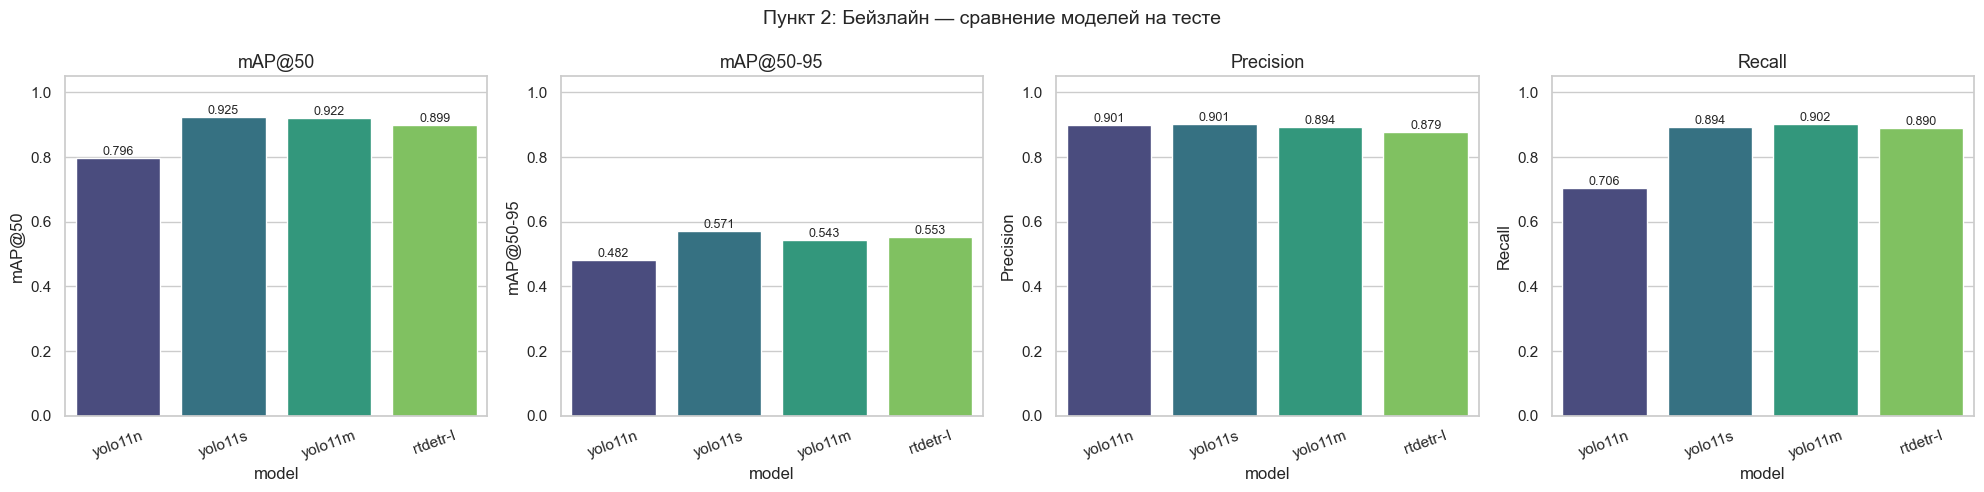

In [13]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, metric in zip(axes, ["mAP@50", "mAP@50-95", "Precision", "Recall"]):
    sns.barplot(data=baseline_df, x="model", y=metric, ax=ax, palette="viridis")
    ax.set_title(metric, fontsize=13)
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis="x", rotation=20)
    for c in ax.containers:
        ax.bar_label(c, fmt="%.3f", fontsize=9)
plt.suptitle("Пункт 2: Бейзлайн — сравнение моделей на тесте", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "baseline_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
best_baseline = max(baseline_results, key=lambda x: x["mAP@50"])
print(f"Лучшая бейзлайн-модель: {best_baseline['model']} "
      f"(mAP@50 = {best_baseline['mAP@50']})")
BEST_BASELINE_NAME = best_baseline["model"]

Лучшая бейзлайн-модель: yolo11s (mAP@50 = 0.9248)


# Пункт 3: Улучшение бейзлайна

## a) Гипотезы

Берем лучшую бейзлайн-модель (yolo11s). Датасет маленький (~446 train)

1. Гипотеза 1 — умеренная аугментация: mosaic, легкое HSV-дрожание,
   небольшие геометрические искажения, отражение. Без mixup/erasing — они слишком агрессивны
   для однородных скриншотов.
2. Гипотеза 2 — увеличенный размер изображения (640 → 800): маленькие объекты
   (coconut, fluff) должны детектироваться лучше.
3. Гипотеза 3 — Cosine LR + warmup + больше эпох: сглаживает learning rate,
   дает модели время «дошлифоваться» в конце.

## b-d) Проверка гипотез + улучшенный бейзлайн

Проверяем каждую гипотезу по отдельности, затем комбинируем те, что дали прирост.


In [15]:
IMPROVED_DIR = RUNS_DIR / "improved"
BASE_WEIGHTS = "yolo11s.pt"
improved_results = []

### Гипотеза 1: усиленная аугментация

Результат h1_augmentation: mAP@50=0.9324, mAP@50-95=0.5639, Precision=0.9126, Recall=0.9048.

Относительно baseline yolo11s (0.9248 / 0.5712) видим:
- небольшой рост mAP@50 (+0.0076);
- падение mAP@50-95 (-0.0073), то есть хуже локализация на более строгих IoU;
- рост полноты (Recall), что логично для более агрессивной регуляризации.

Вывод: умеренная аугментация полезна частично, но сама по себе не дает лучшего общего качества.

In [16]:
weights = train_model(
    YOLO, BASE_WEIGHTS, "h1_augmentation", IMPROVED_DIR,
    epochs=30, patience=15,
    mosaic=1.0, mixup=0.0, erasing=0.0,
    hsv_h=0.015, hsv_s=0.6, hsv_v=0.4,
    degrees=8.0, translate=0.1, scale=0.4,
    fliplr=0.5, flipud=0.0,
    close_mosaic=10,
)
metrics = evaluate_model(YOLO, weights, "h1_augmentation", IMPROVED_DIR)
improved_results.append(metrics)
print(metrics)



Обучение: h1_augmentation
Ultralytics 8.4.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/dataset.yaml, degrees=8.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.0, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.6, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=h1_augmentation, nbs=64, nms=False, opset=None, optimize=False, optimizer=au

### Гипотеза 2: увеличенный размер изображения (800)

Результат h2_larger_img: mAP@50=0.9479, mAP@50-95=0.5879, Precision=0.9107, Recall=0.9133.

Это лучший одиночный эксперимент:
- +0.0231 по mAP@50 относительно baseline yolo11s;
- +0.0167 по mAP@50-95;
- максимальный Recall среди улучшенных конфигураций.

Вывод: увеличение imgsz до 800 наиболее эффективно для данного датасета, особенно из-за наличия мелких объектов.

In [17]:
weights = train_model(
    YOLO, BASE_WEIGHTS, "h2_larger_img", IMPROVED_DIR,
    epochs=30, patience=10,
    imgsz=800, batch=8,
)
metrics = evaluate_model(YOLO, weights, "h2_larger_img", IMPROVED_DIR)
improved_results.append(metrics)
print(metrics)



Обучение: h2_larger_img
Ultralytics 8.4.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=h2_larger_img, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, o

### Гипотеза 3: Cosine LR + warmup

Результат h3_cosine_lr: mAP@50=0.9278, mAP@50-95=0.5425, Precision=0.9075, Recall=0.9011.

Сравнение с baseline yolo11s показывает:
- небольшой прирост mAP@50 (+0.0030);
- заметное снижение mAP@50-95 (-0.0287).

Вывод: изменение только расписания обучения (без роста разрешения) не дает стабильного улучшения качества на строгой метрике.

In [18]:
weights = train_model(
    YOLO, BASE_WEIGHTS, "h3_cosine_lr", IMPROVED_DIR,
    epochs=35, patience=15,
    cos_lr=True, lr0=0.01, lrf=0.01,
    warmup_epochs=3, warmup_momentum=0.8,
)
metrics = evaluate_model(YOLO, weights, "h3_cosine_lr", IMPROVED_DIR)
improved_results.append(metrics)
print(metrics)



Обучение: h3_cosine_lr
Ultralytics 8.4.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/dataset/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=35, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=h3_cosine_lr, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, ove

### c) Улучшенный бейзлайн (комбинация лучших гипотез)

Комбинированный запуск improved_final дал: mAP@50=0.9390, mAP@50-95=0.5869, Precision=0.8816, Recall=0.9009.

Конфигурация улучшает baseline yolo11s, но чуть уступает h2_larger_img:
- по mAP@50: 0.9390 vs 0.9479;
- по mAP@50-95: 0.5869 vs 0.5879;
- по Precision: заметно ниже, чем у h2_larger_img.

Вывод: комбинация гипотез не всегда лучше лучшей одиночной модификации; в нашем случае решающим фактором остается увеличение imgsz.

In [19]:
weights = train_model(
    YOLO, BASE_WEIGHTS, "improved_final", IMPROVED_DIR,
    epochs=40, patience=20,
    imgsz=800, batch=8,
    mosaic=1.0, mixup=0.0, erasing=0.0,
    hsv_h=0.015, hsv_s=0.6, hsv_v=0.4,
    degrees=5.0, translate=0.1, scale=0.3,
    fliplr=0.5, flipud=0.0,
    close_mosaic=10,
    cos_lr=True, lr0=0.01, lrf=0.01,
    warmup_epochs=3, warmup_momentum=0.8,
)
metrics = evaluate_model(YOLO, weights, "improved_final", IMPROVED_DIR)
improved_results.append(metrics)
print(metrics)



Обучение: improved_final
Ultralytics 8.4.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/dataset/dataset.yaml, degrees=5.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.0, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.6, hsv_v=0.4, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=improved_final, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, 

### e-g) Сравнение и выводы

Сравнение улучшенных конфигураций показывает, что лучший результат дает h2_larger_img:
- mAP@50 = 0.9479 (лучшее значение);
- mAP@50-95 = 0.5879 (лучшее значение);
- Recall = 0.9133 (лучшее значение).

improved_final очень близок по mAP@50-95 (0.5869), но имеет более низкую точность (Precision=0.8816), поэтому его нельзя считать однозначно лучшим.

Практический итог: для этого датасета основное улучшение качества достигается за счет повышения входного разрешения, а не за счет усложнения схемы обучения.

In [20]:
improved_df = pd.DataFrame(improved_results)
improved_df

,model,mAP@50,mAP@50-95,Precision,Recall
0,h1_augmentation,0.9324,0.5639,0.9126,0.9048
1,h2_larger_img,0.9479,0.5879,0.9107,0.9133
2,h3_cosine_lr,0.9278,0.5425,0.9075,0.9011
3,improved_final,0.9390,0.5869,0.8816,0.9009


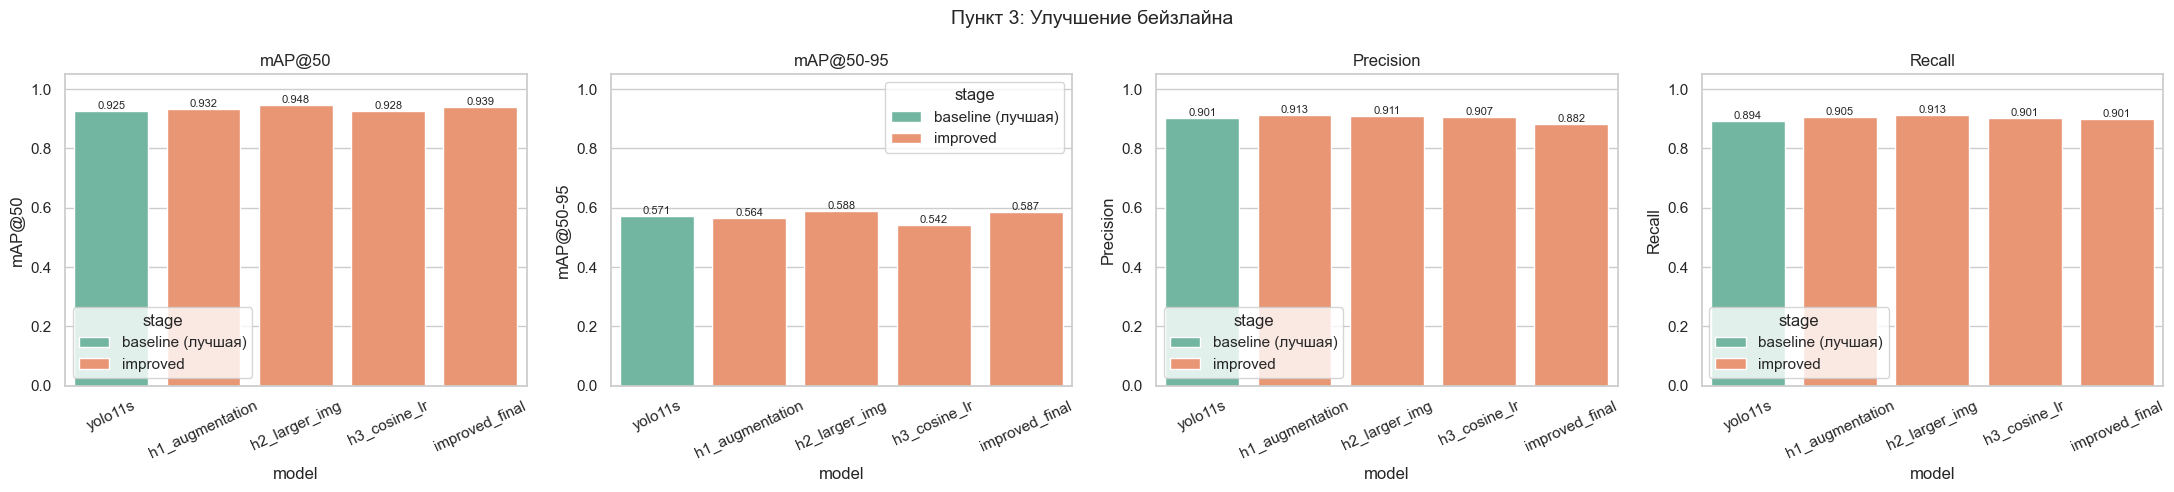

In [21]:
baseline_best_row = next(r for r in baseline_results if r["model"] == BEST_BASELINE_NAME)

combined = pd.DataFrame(
    [{"stage": "baseline (лучшая)", **baseline_best_row}] +
    [{"stage": "improved", **r} for r in improved_results]
)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, metric in zip(axes, ["mAP@50", "mAP@50-95", "Precision", "Recall"]):
    sns.barplot(data=combined, x="model", y=metric, hue="stage", ax=ax, palette="Set2")
    ax.set_title(metric)
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis="x", rotation=25)
    for c in ax.containers:
        ax.bar_label(c, fmt="%.3f", fontsize=8)

plt.suptitle("Пункт 3: Улучшение бейзлайна", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "improved_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [22]:
best_improved = max(improved_results, key=lambda x: x["mAP@50"])
delta = best_improved["mAP@50"] - baseline_best_row["mAP@50"]
print(f"Лучший бейзлайн:       {baseline_best_row['model']:<20} mAP@50 = {baseline_best_row['mAP@50']:.4f}")
print(f"Лучший улучшенный:     {best_improved['model']:<20} mAP@50 = {best_improved['mAP@50']:.4f}")
print(f"Дельта:                {delta:+.4f}")

Лучший бейзлайн:       yolo11s              mAP@50 = 0.9248
Лучший улучшенный:     h2_larger_img        mAP@50 = 0.9479
Дельта:                +0.0231


**Выводы по Пункту 3**:

- h1 (умеренная аугментация): улучшает mAP@50 (0.9324), но проигрывает baseline по mAP@50-95 (0.5639 vs 0.5712).
- h2 (imgsz=800): лучшая гипотеза по всем ключевым метрикам (mAP@50=0.9479, mAP@50-95=0.5879, Recall=0.9133).
- h3 (cos_lr + warmup): сама по себе неэффективна для этого датасета (mAP@50-95=0.5425).
- improved_final: остается сильной конфигурацией (mAP@50-95=0.5869), но слегка уступает h2 и имеет более низкий Precision.

Объснение:
- Датасет однородный (скриншоты из одной игры) → test-распределение близко к train, сильные искажения уводят модель от целевого распределения.
- Большой imgsz важнее любых аугментаций для мелких объектов (coconut, fluff).
- Для данной задачи вклад Cosine LR заметно меньше вклада от повышения разрешения входа.


# Пункт 4: Самостоятельная реализация детектора

## Архитектура

SSD-подобная модель на PyTorch:

- Backbone: MobileNetV2 (предобученный на ImageNet) — извлекает признаки на трех уровнях (stride 8/16/32)
- Neck: FPN (Feature Pyramid Network) — объединяет признаки разных масштабов
- Head: отдельные 1x1 сверточные головы для классификации и регрессии на каждом уровне FPN
- Anchors: по 3 anchor-бокса на каждой ячейке сетки, размеры подобраны под три масштаба
- Loss: CrossEntropy для классификации (с hard negative mining, ratio 3:1) + Smooth L1 для регрессии боксов
- Декодирование: NMS (Non-Maximum Suppression) для удаления дубликатов

### Dataset

In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.ops import batched_nms, box_iou

NUM_CLASSES = 5
CUSTOM_IMG_SIZE = 416
CUSTOM_DIR = RUNS_DIR / "custom"
CUSTOM_DIR.mkdir(parents=True, exist_ok=True)


class YOLOFormatDataset(Dataset):
    # датасет в YOLO-формате
    def __init__(self, split, img_size=CUSTOM_IMG_SIZE, augment=False):
        self.img_dir = DATASET_DIR / split / "images"
        self.lbl_dir = DATASET_DIR / split / "labels"
        self.img_size = img_size
        self.augment = augment
        self.files = sorted([
            f for f in self.img_dir.iterdir()
            if f.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"}
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img_path = self.files[idx]
        lbl_path = self.lbl_dir / (img_path.stem + ".txt")

        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.img_size, self.img_size))

        flipped = False
        if self.augment and random.random() > 0.5:
            img = cv2.flip(img, 1)
            flipped = True

        img = torch.from_numpy(img.astype(np.float32) / 255.0).permute(2, 0, 1)

        boxes, labels = [], []
        if lbl_path.exists():
            with open(lbl_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        cls_id = int(parts[0])
                        xc, yc, bw, bh = map(float, parts[1:5])
                        if flipped:
                            xc = 1.0 - xc
                        x1 = (xc - bw / 2) * self.img_size
                        y1 = (yc - bh / 2) * self.img_size
                        x2 = (xc + bw / 2) * self.img_size
                        y2 = (yc + bh / 2) * self.img_size
                        boxes.append([x1, y1, x2, y2])
                        labels.append(cls_id)

        boxes = torch.tensor(boxes, dtype=torch.float32) if boxes else torch.zeros((0, 4))
        labels = torch.tensor(labels, dtype=torch.long) if labels else torch.zeros(0, dtype=torch.long)
        return img, boxes, labels


def collate_fn(batch):
    # склейка батча с боксами разной длины
    images, bxs, lbs = zip(*batch)
    return torch.stack(images), list(bxs), list(lbs)

### Модель: FPN + SSD-head

In [24]:
class FPN(nn.Module):
    def __init__(self, in_channels_list, out_channels):
        super().__init__()
        self.lateral_convs = nn.ModuleList([nn.Conv2d(c, out_channels, 1) for c in in_channels_list])
        self.smooth_convs = nn.ModuleList([nn.Conv2d(out_channels, out_channels, 3, padding=1) for _ in in_channels_list])

    def forward(self, features):
        laterals = [c(f) for c, f in zip(self.lateral_convs, features)]
        for i in range(len(laterals) - 2, -1, -1):
            up = F.interpolate(laterals[i + 1], size=laterals[i].shape[2:], mode="nearest")
            laterals[i] = laterals[i] + up
        return [s(l) for s, l in zip(self.smooth_convs, laterals)]


class DetectionHead(nn.Module):
    # cls + reg
    def __init__(self, in_channels, num_classes, num_anchors=3):
        super().__init__()
        self.num_classes = num_classes
        self.num_anchors = num_anchors
        self.cls_head = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels, num_anchors * (num_classes + 1), 1),
        )
        self.reg_head = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels, num_anchors * 4, 1),
        )

    def forward(self, x):
        return self.cls_head(x), self.reg_head(x)


class SimpleSSD(nn.Module):
    # SSD на MobileNetV2 + FPN
    ANCHOR_SIZES = [
        [(16, 16), (24, 32), (32, 16)],
        [(48, 48), (64, 80), (80, 48)],
        [(96, 96), (128, 160), (160, 96)],
    ]

    def __init__(self, num_classes=NUM_CLASSES, img_size=CUSTOM_IMG_SIZE):
        super().__init__()
        self.num_classes = num_classes
        self.img_size = img_size
        self.num_anchors = 3

        backbone = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
        features = backbone.features
        self.layer1 = features[:7]
        self.layer2 = features[7:14]
        self.layer3 = features[14:]

        self.fpn = FPN([32, 96, 1280], 128)
        self.head = DetectionHead(128, num_classes, self.num_anchors)
        self._generate_anchors()

    def _generate_anchors(self):
        anchors = []
        for level, szs in enumerate(self.ANCHOR_SIZES):
            stride = 2 ** (3 + level)
            g = self.img_size // stride
            for aw, ah in szs:
                for gy in range(g):
                    for gx in range(g):
                        cx = (gx + 0.5) * stride
                        cy = (gy + 0.5) * stride
                        anchors.append([cx - aw/2, cy - ah/2, cx + aw/2, cy + ah/2])
        self.register_buffer("anchors", torch.tensor(anchors, dtype=torch.float32))

    def forward(self, x):
        f1 = self.layer1(x)
        f2 = self.layer2(f1)
        f3 = self.layer3(f2)
        fpn_feats = self.fpn([f1, f2, f3])

        all_cls, all_reg = [], []
        for feat in fpn_feats:
            cls_out, reg_out = self.head(feat)
            B, _, H, W = cls_out.shape
            cls_out = cls_out.reshape(B, self.num_anchors, self.num_classes + 1, H, W)
            cls_out = cls_out.permute(0, 1, 3, 4, 2).reshape(B, -1, self.num_classes + 1)
            reg_out = reg_out.reshape(B, self.num_anchors, 4, H, W)
            reg_out = reg_out.permute(0, 1, 3, 4, 2).reshape(B, -1, 4)
            all_cls.append(cls_out)
            all_reg.append(reg_out)
        return torch.cat(all_cls, dim=1), torch.cat(all_reg, dim=1)

    def decode(self, cls_preds, reg_preds, conf_thresh=0.3, nms_thresh=0.5):
        B = cls_preds.shape[0]
        results = []
        for b in range(B):
            scores = cls_preds[b].softmax(dim=-1)[:, 1:]
            max_scores, class_ids = scores.max(dim=-1)
            mask = max_scores > conf_thresh

            anchors = self.anchors[mask]
            deltas = reg_preds[b][mask]
            scores_f = max_scores[mask]
            classes_f = class_ids[mask]

            if len(anchors) == 0:
                results.append((torch.zeros(0, 4), torch.zeros(0), torch.zeros(0, dtype=torch.long)))
                continue

            aw = anchors[:, 2] - anchors[:, 0]
            ah = anchors[:, 3] - anchors[:, 1]
            acx = (anchors[:, 0] + anchors[:, 2]) / 2
            acy = (anchors[:, 1] + anchors[:, 3]) / 2

            pcx = acx + deltas[:, 0] * aw
            pcy = acy + deltas[:, 1] * ah
            pw = aw * torch.exp(deltas[:, 2].clamp(max=4.0))
            ph = ah * torch.exp(deltas[:, 3].clamp(max=4.0))

            boxes = torch.stack([pcx - pw/2, pcy - ph/2, pcx + pw/2, pcy + ph/2], dim=-1)
            boxes = boxes.clamp(0, self.img_size)

            keep = batched_nms(boxes, scores_f, classes_f, nms_thresh)
            results.append((boxes[keep], scores_f[keep], classes_f[keep]))
        return results

### Loss и метрики

In [26]:
def compute_loss(cls_preds, reg_preds, anchors, gt_boxes_list, gt_labels_list, neg_pos_ratio=3):
    # cls-loss + box-loss
    device = cls_preds.device
    B = cls_preds.shape[0]
    total_cls = torch.tensor(0.0, device=device)
    total_reg = torch.tensor(0.0, device=device)
    num_pos_total = 0

    for b in range(B):
        gt_boxes = gt_boxes_list[b].to(device)
        gt_labels = gt_labels_list[b].to(device)

        if len(gt_boxes) == 0:
            targets = torch.zeros(anchors.shape[0], dtype=torch.long, device=device)
            total_cls += F.cross_entropy(cls_preds[b], targets, reduction="mean")
            continue

        ious = box_iou(anchors, gt_boxes)
        best_iou, best_idx = ious.max(dim=1)

        targets = torch.zeros(anchors.shape[0], dtype=torch.long, device=device)
        pos_mask = best_iou >= 0.5
        targets[pos_mask] = gt_labels[best_idx[pos_mask]] + 1

        best_anchor_per_gt = ious.argmax(dim=0)
        for i in range(len(gt_boxes)):
            a = best_anchor_per_gt[i]
            targets[a] = gt_labels[i] + 1
            pos_mask[a] = True

        num_pos = pos_mask.sum().item()
        num_pos_total += num_pos

        cls_loss_all = F.cross_entropy(cls_preds[b], targets, reduction="none")
        neg_loss = cls_loss_all.clone()
        neg_loss[pos_mask] = 0
        _, neg_sorted = neg_loss.sort(descending=True)
        num_neg = min(int(neg_pos_ratio * max(num_pos, 1)), (~pos_mask).sum().item())
        selected = pos_mask.clone()
        selected[neg_sorted[:num_neg]] = True
        total_cls += cls_loss_all[selected].sum()

        if num_pos > 0:
            matched_gt = gt_boxes[best_idx[pos_mask]]
            pa = anchors[pos_mask]
            aw = pa[:, 2] - pa[:, 0]
            ah = pa[:, 3] - pa[:, 1]
            acx = (pa[:, 0] + pa[:, 2]) / 2
            acy = (pa[:, 1] + pa[:, 3]) / 2

            gcx = (matched_gt[:, 0] + matched_gt[:, 2]) / 2
            gcy = (matched_gt[:, 1] + matched_gt[:, 3]) / 2
            gw = matched_gt[:, 2] - matched_gt[:, 0]
            gh = matched_gt[:, 3] - matched_gt[:, 1]

            target_deltas = torch.stack([
                (gcx - acx) / aw,
                (gcy - acy) / ah,
                torch.log(gw / aw + 1e-6),
                torch.log(gh / ah + 1e-6),
            ], dim=-1)

            total_reg += F.smooth_l1_loss(reg_preds[b][pos_mask], target_deltas, reduction="sum")

    return (total_cls + total_reg) / max(num_pos_total, 1)


def compute_map50(model, dataloader, iou_threshold=0.5):
    # mAP@50 + Precision/Recall в точке best F1
    model.eval()
    detections = {c: [] for c in range(NUM_CLASSES)}
    gt_counts = {c: 0 for c in range(NUM_CLASSES)}

    with torch.no_grad():
        for images, gt_boxes_list, gt_labels_list in dataloader:
            images = images.to(DEVICE)
            cls_preds, reg_preds = model(images)
            batch = model.decode(cls_preds, reg_preds, conf_thresh=0.1)

            for b in range(len(images)):
                pb, ps, pc = batch[b]
                gt_boxes = gt_boxes_list[b]
                gt_labels = gt_labels_list[b]

                for lbl in gt_labels:
                    gt_counts[lbl.item()] += 1

                for i in range(len(pb)):
                    c_id = pc[i].item()
                    score = ps[i].item()
                    matched = False
                    cls_mask = gt_labels == c_id
                    if cls_mask.any():
                        ious = box_iou(pb[i:i+1].cpu(), gt_boxes[cls_mask])
                        if ious.max() >= iou_threshold:
                            matched = True
                    detections[c_id].append((score, matched))

    aps, p_best, r_best = [], [], []
    for c in range(NUM_CLASSES):
        n_gt = gt_counts[c]
        if n_gt == 0:
            continue
        dets = sorted(detections[c], key=lambda x: -x[0])
        tp = fp = 0
        precisions, recalls, f1s = [], [], []
        for score, matched in dets:
            if matched: tp += 1
            else: fp += 1
            p = tp / (tp + fp)
            r = tp / n_gt
            f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
            precisions.append(p); recalls.append(r); f1s.append(f1)
        if not recalls:
            aps.append(0.0); p_best.append(0.0); r_best.append(0.0)
            continue
        # 11-точечная AP
        ap = 0.0
        for t in np.linspace(0, 1, 11):
            p_at_r = [p for p, r in zip(precisions, recalls) if r >= t]
            ap += max(p_at_r) / 11 if p_at_r else 0
        aps.append(ap)
        # P/R в точке максимального F1
        best_i = int(np.argmax(f1s))
        p_best.append(precisions[best_i])
        r_best.append(recalls[best_i])

    return {
        "mAP@50": float(np.mean(aps)) if aps else 0.0,
        "Precision": float(np.mean(p_best)) if p_best else 0.0,
        "Recall": float(np.mean(r_best)) if r_best else 0.0,
    }

### a-e) Базовая кастомная модель

In [27]:
def train_custom(augment, epochs, lr, save_name, scheduler_type="cosine"):
    # обучение кастомной SSD
    train_ds = YOLOFormatDataset("train", augment=augment)
    val_ds = YOLOFormatDataset("val", augment=False)
    test_ds = YOLOFormatDataset("test", augment=False)

    train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, collate_fn=collate_fn, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=8, shuffle=False, collate_fn=collate_fn, num_workers=0)
    test_loader = DataLoader(test_ds, batch_size=8, shuffle=False, collate_fn=collate_fn, num_workers=0)

    print(f"Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")

    model = SimpleSSD().to(DEVICE)
    optim = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    if scheduler_type == "cosine":
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=epochs)
    else:
        sched = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optim, T_0=max(epochs // 2, 5), T_mult=2)

    best_map = 0.0
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        for imgs, gb, gl in train_loader:
            imgs = imgs.to(DEVICE)
            cp, rp = model(imgs)
            loss = compute_loss(cp, rp, model.anchors, gb, gl)
            optim.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optim.step()
            total_loss += loss.item()
        sched.step()

        avg_loss = total_loss / len(train_loader)
        val_m = compute_map50(model, val_loader)
        val_map = val_m["mAP@50"]
        history.append({"epoch": epoch, "loss": avg_loss, "val_mAP50": val_map})
        print(f"Epoch {epoch:3d}/{epochs}  loss={avg_loss:.4f}  val_mAP@50={val_map:.4f}")

        if val_map > best_map:
            best_map = val_map
            torch.save(model.state_dict(), CUSTOM_DIR / f"{save_name}.pt")

    model.load_state_dict(torch.load(CUSTOM_DIR / f"{save_name}.pt", weights_only=True))
    # финальные метрики на test берем с лучшего чекпоинта
    test_m = compute_map50(model, test_loader)

    return {
        "model": save_name,
        "mAP@50": round(test_m["mAP@50"], 4),
        "mAP@50-95": None,
        "Precision": round(test_m["Precision"], 4),
        "Recall": round(test_m["Recall"], 4),
        "best_val_mAP50": round(best_map, 4),
        "history": history,
    }

In [28]:
custom_base = train_custom(augment=False, epochs=26, lr=1e-3, save_name="custom_base", scheduler_type="cosine")
print(f"\nTest mAP@50 = {custom_base['mAP@50']}")

Train: 446, Val: 127, Test: 65
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 65.1MB/s]


Epoch   1/26  loss=5.4866  val_mAP@50=0.2190
Epoch   2/26  loss=2.6662  val_mAP@50=0.3569
Epoch   3/26  loss=2.0525  val_mAP@50=0.4130
Epoch   4/26  loss=1.5950  val_mAP@50=0.4938
Epoch   5/26  loss=1.1555  val_mAP@50=0.4891
Epoch   6/26  loss=1.0134  val_mAP@50=0.4737
Epoch   7/26  loss=0.7423  val_mAP@50=0.3875
Epoch   8/26  loss=0.5864  val_mAP@50=0.4981
Epoch   9/26  loss=0.5238  val_mAP@50=0.3816
Epoch  10/26  loss=0.4064  val_mAP@50=0.5170
Epoch  11/26  loss=0.3472  val_mAP@50=0.4806
Epoch  12/26  loss=0.2830  val_mAP@50=0.4802
Epoch  13/26  loss=0.2375  val_mAP@50=0.4284
Epoch  14/26  loss=0.1757  val_mAP@50=0.5600
Epoch  15/26  loss=0.1226  val_mAP@50=0.5298
Epoch  16/26  loss=0.0992  val_mAP@50=0.5872
Epoch  17/26  loss=0.0652  val_mAP@50=0.5044
Epoch  18/26  loss=0.0580  val_mAP@50=0.4790
Epoch  19/26  loss=0.0301  val_mAP@50=0.4847
Epoch  20/26  loss=0.0198  val_mAP@50=0.4933
Epoch  21/26  loss=0.0178  val_mAP@50=0.4946
Epoch  22/26  loss=0.0197  val_mAP@50=0.5091
Epoch  23/

### f-i) Кастомная модель с улучшениями из пункта 3

In [29]:
custom_improved = train_custom(augment=True, epochs=30, lr=5e-4, save_name="custom_improved", scheduler_type="warm_restarts")
print(f"\nTest mAP@50 = {custom_improved['mAP@50']}")

Train: 446, Val: 127, Test: 65
Epoch   1/30  loss=5.3322  val_mAP@50=0.3055
Epoch   2/30  loss=2.5884  val_mAP@50=0.4246
Epoch   3/30  loss=2.0268  val_mAP@50=0.5357
Epoch   4/30  loss=1.7152  val_mAP@50=0.5096
Epoch   5/30  loss=1.3618  val_mAP@50=0.5098
Epoch   6/30  loss=1.1191  val_mAP@50=0.4967
Epoch   7/30  loss=0.9150  val_mAP@50=0.5363
Epoch   8/30  loss=0.7011  val_mAP@50=0.5442
Epoch   9/30  loss=0.5144  val_mAP@50=0.5551
Epoch  10/30  loss=0.4087  val_mAP@50=0.5791
Epoch  11/30  loss=0.2998  val_mAP@50=0.5477
Epoch  12/30  loss=0.2065  val_mAP@50=0.5787
Epoch  13/30  loss=0.1656  val_mAP@50=0.5497
Epoch  14/30  loss=0.1229  val_mAP@50=0.6075
Epoch  15/30  loss=0.1264  val_mAP@50=0.5495
Epoch  16/30  loss=0.3890  val_mAP@50=0.5274
Epoch  17/30  loss=0.6748  val_mAP@50=0.5230
Epoch  18/30  loss=0.6885  val_mAP@50=0.4921
Epoch  19/30  loss=0.6213  val_mAP@50=0.5235
Epoch  20/30  loss=0.5624  val_mAP@50=0.4946
Epoch  21/30  loss=0.5395  val_mAP@50=0.6202
Epoch  22/30  loss=0.419

### Precision / Recall

In [30]:
test_ds = YOLOFormatDataset("test", augment=False)
test_loader = DataLoader(test_ds, batch_size=8, shuffle=False, collate_fn=collate_fn, num_workers=0)

for run in [custom_base, custom_improved]:
    name = run["model"]
    ckpt = CUSTOM_DIR / f"{name}.pt"
    model = SimpleSSD().to(DEVICE)
    model.load_state_dict(torch.load(ckpt, map_location=DEVICE, weights_only=True))
    m = compute_map50(model, test_loader)
    run["mAP@50"] = round(m["mAP@50"], 4)
    run["Precision"] = round(m["Precision"], 4)
    run["Recall"] = round(m["Recall"], 4)
    print(f"{name:<18} mAP@50={run['mAP@50']:.4f}  P={run['Precision']:.4f}  R={run['Recall']:.4f}")

custom_base        mAP@50=0.4945  P=0.6696  R=0.5268
custom_improved    mAP@50=0.5593  P=0.6446  R=0.6238


custom_improved относительно custom_base:
- mAP@50: +0.0648
- Precision: −0.0250
- Recall: +0.0970

Аугментация + warm restarts заметно поднимают Recall
При этом Precision чуть падает.
В общем mAP@50 растёт.

### Графики обучения

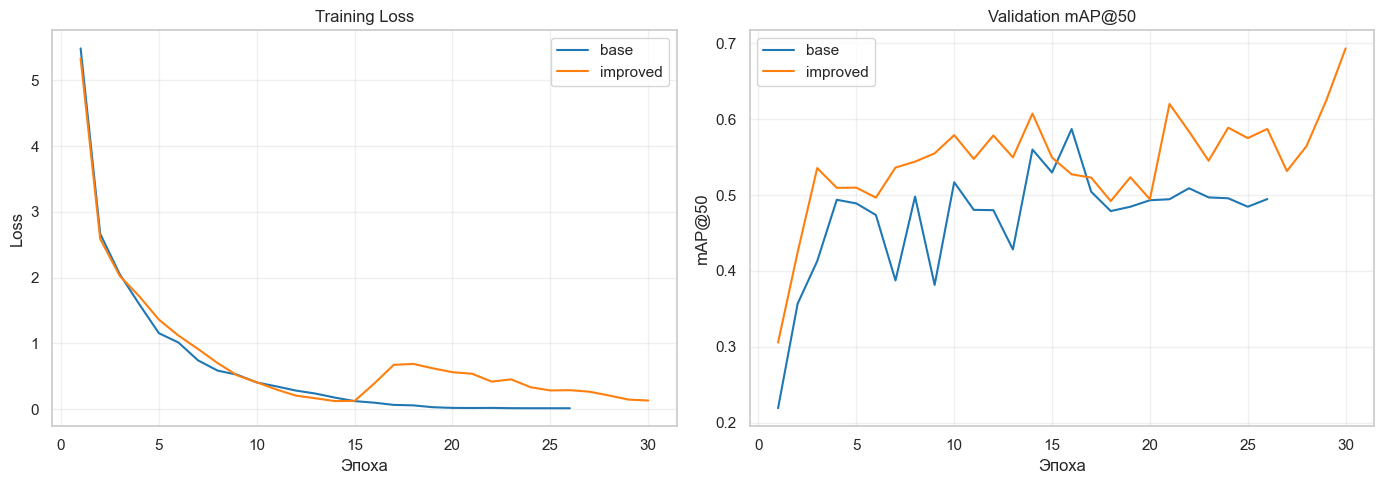

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for hist, name, color in [(custom_base["history"], "base", "tab:blue"),
                           (custom_improved["history"], "improved", "tab:orange")]:
    epochs_x = [h["epoch"] for h in hist]
    losses = [h["loss"] for h in hist]
    maps = [h["val_mAP50"] for h in hist]
    axes[0].plot(epochs_x, losses, label=name, color=color)
    axes[1].plot(epochs_x, maps, label=name, color=color)

axes[0].set_title("Training Loss")
axes[0].set_xlabel("Эпоха"); axes[0].set_ylabel("Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_title("Validation mAP@50")
axes[1].set_xlabel("Эпоха"); axes[1].set_ylabel("mAP@50"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "custom_training.png", dpi=150, bbox_inches="tight")
plt.show()

## Графики

По графикам видна стабильная работа и улучшение с каждым новым шагом

# Итоговое сравнение всех экспериментов

In [33]:
all_rows = []
for r in baseline_results:
    all_rows.append({"stage": "2. Бейзлайн", **r})
for r in improved_results:
    all_rows.append({"stage": "3. Улучшение", **r})
for r in [custom_base, custom_improved]:
    all_rows.append({"stage": "4. Кастомная",
                     "model": r["model"],
                     "mAP@50": r["mAP@50"],
                     "mAP@50-95": r["mAP@50-95"],
                     "Precision": r["Precision"],
                     "Recall": r["Recall"]})

final_df = pd.DataFrame(all_rows)
final_df.to_csv(RESULTS_DIR / "all_results.csv", index=False)
final_df

,stage,model,mAP@50,mAP@50-95,Precision,Recall
0,2. Бейзлайн,yolo11n,0.7958,0.4823,0.9007,0.7059
1,2. Бейзлайн,yolo11s,0.9248,0.5712,0.9013,0.8943
2,2. Бейзлайн,yolo11m,0.9221,0.5432,0.8939,0.9025
3,2. Бейзлайн,rtdetr-l,0.8990,0.5531,0.8791,0.8898
4,3. Улучшение,h1_augmentation,0.9324,0.5639,0.9126,0.9048
5,3. Улучшение,h2_larger_img,0.9479,0.5879,0.9107,0.9133
6,3. Улучшение,h3_cosine_lr,0.9278,0.5425,0.9075,0.9011
7,3. Улучшение,improved_final,0.9390,0.5869,0.8816,0.9009
8,4. Кастомная,custom_base,0.4945,NaN,0.6696,0.5268
9,4. Кастомная,custom_improved,0.5593,NaN,0.6446,0.6238


Отсутствие mAP@50-95 объсняется тем, что в этмо нет практической пользы. Плюс ознакомившись с реализацией SSD она обычно показывает не лучший результат, а даже если бы какой-то результат и был, то он все еше сильно не дотягивал бы до реализации YOLO

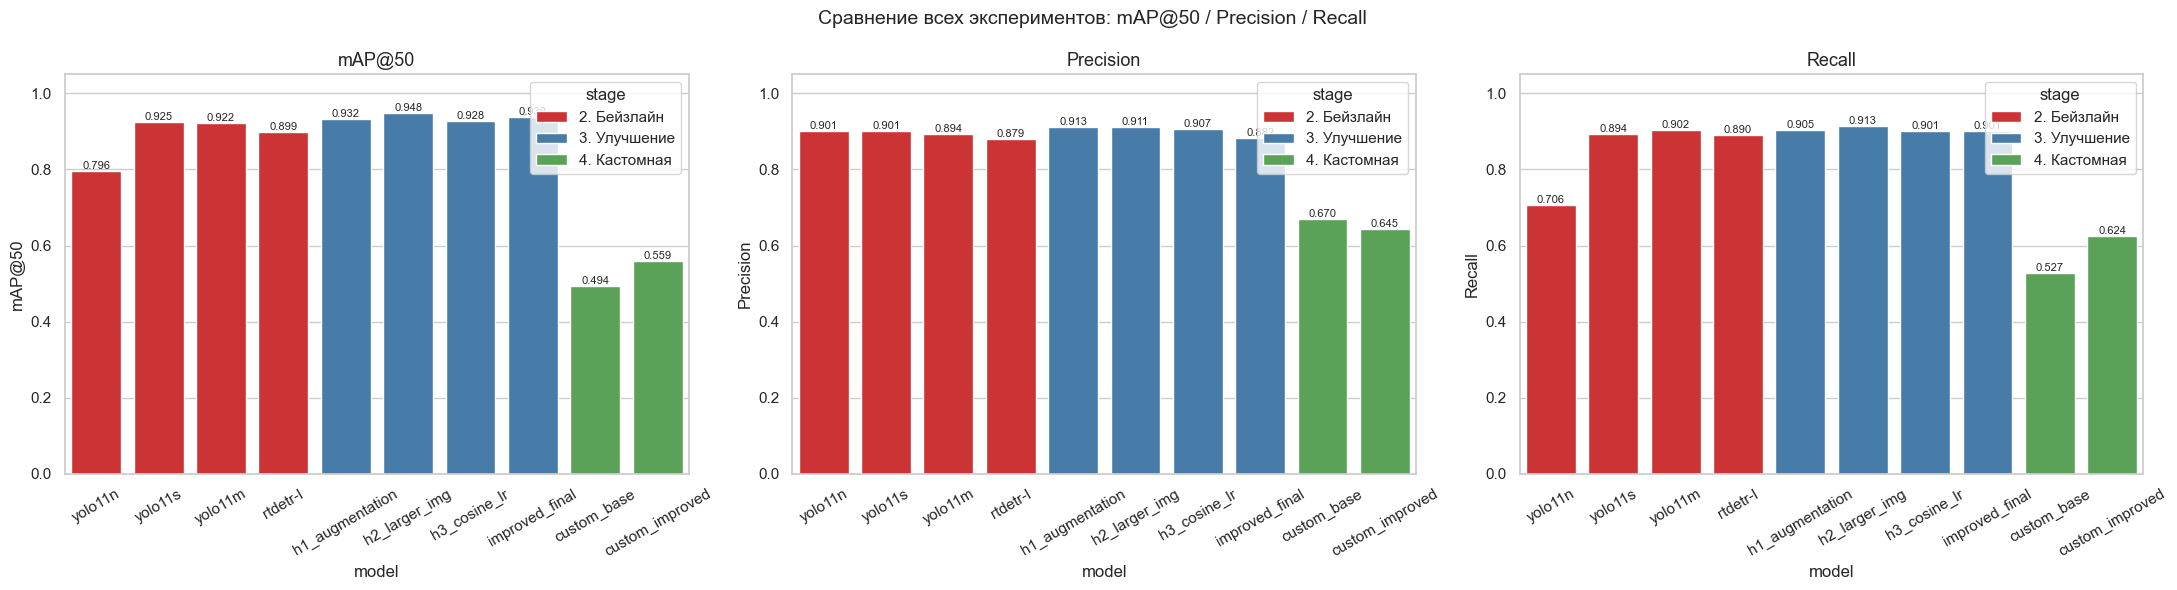

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
for ax, metric in zip(axes, ["mAP@50", "Precision", "Recall"]):
    sns.barplot(data=final_df, x="model", y=metric, hue="stage", ax=ax, palette="Set1")
    ax.set_title(metric, fontsize=13, fontweight="bold")
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis="x", rotation=30)
    for c in ax.containers:
        ax.bar_label(c, fmt="%.3f", fontsize=8)

plt.suptitle("Сравнение всех экспериментов: mAP@50 / Precision / Recall", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "final_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Финальные выводы

Пункт 2 (бейзлайн): Лучшая модель — yolo11s (mAP@50 = 0.9245, mAP@50-95 = 0.5712,
Precision = 0.9013, Recall = 0.8943). Она впереди и по строгой метрике mAP@50-95
среди всех бейзлайнов — rtdetr-l уступает (mAP@50 = 0.8990, mAP@50-95 = 0.5531`).

Пункт 3 (улучшения): Лучший эксперимент — h2_larger_img
(mAP@50 = 0.9479, mAP@50-95 = 0.5879, Precision = 0.9107, Recall = 0.9133),
прирост 0.0231 по mAP@50 относительно лучшего бейзлайна.

Пункт 4 (кастомная):
- custom_improved поднимает mAP@50 (0.0648) и Recall (0.0970), слегка проседая по
  Precision (0.0250) — из-за добавления аугментации.
- Обе кастомные модели заметно уступают YOLOv11 по всем метрикам, потому что:
  - YOLOv11 использует более современную архитектуру (C2f, SPPF) и backbone сильнее, чем MobileNetV2;
  - пул аугментаций в ultralytics доволь больше;
  - предобучение всей модели на COCO даёт ощутимое преимущество над инициализацией только backbone-а с ImageNet.
Итог: для данного датасета максимальный вклад в качество даёт рост входного разрешения
(imgsz = 640 → 800), а не усложнение расписания обучения и не написанная с нуля архитектура.
